# Лабораторная работа №2
## Метод k-ближайших соседей и непараметрические методы регрессии

## Импорт необходимых библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_absolute_error, r2_score

## Загрузка и Разведочный анализ (EDA)

In [2]:
df = pd.read_csv("car_web_scraped_dataset.csv")

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df["miles"] = (
    df["miles"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" miles", "", regex=False)
    .str.strip()
)

df["miles"] = pd.to_numeric(df["miles"], errors="coerce")

df = df.dropna()

df = df.drop("name", axis=1)

print(f"Размеры таблицы: {df.shape[0]} автомобилей и {df.shape[1]} параметров")

condition_impact = df.groupby("condition")["price"].median()
print("\nМедианная стоимость ($) в зависимости от состояния автомобиля:\n", condition_impact)

df.head(3)

Размеры таблицы: 2840 автомобилей и 5 параметров

Медианная стоимость ($) в зависимости от состояния автомобиля:
 condition
1 accident reported, 1 Owner       22998.0
1 accident reported, 2 Owners      17998.0
1 accident reported, 3 Owners      16198.5
1 accident reported, 4 Owners      13399.0
1 accident reported, 5 Owners      11497.0
2 accidents reported, 1 Owner      21499.0
2 accidents reported, 2 Owners     15496.5
2 accidents reported, 3 Owners     15645.0
2 accidents reported, 4 Owners     14798.5
2 accidents reported, 5 Owners     10131.5
3 accidents reported, 1 Owner      14987.0
3 accidents reported, 2 Owners     14996.5
3 accidents reported, 3 Owners     20998.0
3 accidents reported, 4 Owners     14230.5
4 accidents reported, 2 Owners      8650.0
4 accidents reported, 3 Owners     16999.0
5 accidents reported, 5 Owners      9995.0
No accidents reported, 0 Owners    15777.0
No accidents reported, 1 Owner     26991.0
No accidents reported, 2 Owners    19998.0
No accidents rep

,year,miles,color,condition,price
0,2022,41406,"Gray exterior, Black interior","No accidents reported, 1 Owner",15988
1,2021,15138,"White exterior, Black interior","1 accident reported, 1 Owner",38008
2,2022,32879,"Silver exterior, Unknown interior","No accidents reported, 1 Owner",24988


### Датасет содержит 2840 автомобилей и 5 параметров. Для анализа была рассчитана медианная стоимость автомобилей в зависимости от состояния. По результатам видно, что автомобили без аварий и с одним владельцем имеют наиболее высокую медианную стоимость - 26 991. Стоимость автомобилей снижается с увеличением количества аварий и владельцев, но встречаются исключения, это связано с особенностями отдельных автомобилей

## Подготовка признаков

In [3]:
df = pd.get_dummies(df, drop_first=True)
df.head(3)

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

number_cols = ['year', 'miles']
scaler = StandardScaler()
X_train[number_cols] = scaler.fit_transform(X_train[number_cols])
X_test[number_cols] = scaler.transform(X_test[number_cols])

X_train.head(3)

,year,miles,"color_Black exterior, Black interior","color_Black exterior, Brown interior","color_Black exterior, Gray interior","color_Black exterior, Red interior","color_Black exterior, Unknown interior","color_Black exterior, White interior","color_Blue exterior, Beige interior","color_Blue exterior, Black interior",...,"condition_4 accidents reported, 3 Owners","condition_5 accidents reported, 5 Owners","condition_No accidents reported, 0 Owners","condition_No accidents reported, 1 Owner","condition_No accidents reported, 2 Owners","condition_No accidents reported, 3 Owners","condition_No accidents reported, 4 Owners","condition_No accidents reported, 5 Owners","condition_No accidents reported, 7 Owners","condition_No accidents reported, 8 Owners"
940,0.890734,-0.868891,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
741,0.607652,-0.659915,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2801,0.324571,-0.969484,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


## Поиск оптимального числа соседей ($k$)

<function matplotlib.pyplot.show(close=None, block=None)>

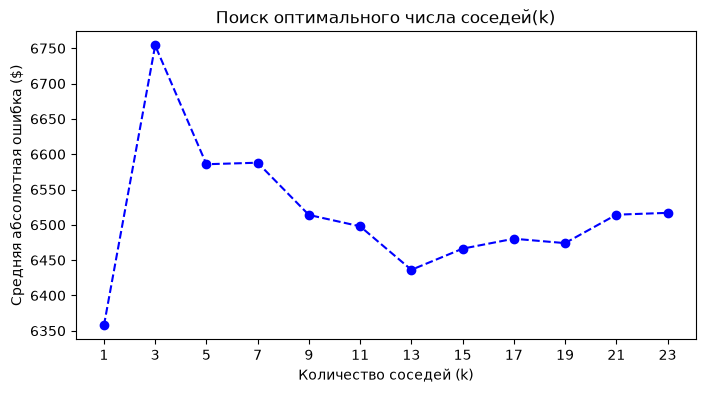

In [4]:
errors = []
k_values = range(1, 25, 2)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    errors.append(mean_absolute_error(y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(k_values, errors, marker ="o", linestyle="dashed", color="blue")
plt.title("Поиск оптимального числа соседей(k)")
plt.xlabel("Количество соседей (k)")
plt.ylabel("Средняя абсолютная ошибка ($)")
plt.xticks(k_values)
plt.show

## Сравнение метрик расстояния Минковского

In [5]:
best_k = 13

knn_euclidean = KNeighborsRegressor(n_neighbors=best_k, p=2)
knn_euclidean.fit(X_train, y_train)
y_pred_euc = knn_euclidean.predict(X_test)

knn_manhattan = KNeighborsRegressor(n_neighbors=best_k, p=1)
knn_manhattan.fit(X_train, y_train)
y_pred_man = knn_manhattan.predict(X_test)

print("=== Сравнение метрик расстояния ===")
print(f"Евклидово расстояние (p=2): MAE = ${mean_absolute_error(y_test, y_pred_euc):,.2f} | R2 = {r2_score(y_test,y_pred_euc):,.2f}")
print(f"Манхэттенское расстояние (p=1): MAE = ${mean_absolute_error(y_test, y_pred_man):,.2f} | R2 = {r2_score(y_test,y_pred_man):,.2f}")

=== Сравнение метрик расстояния ===
Евклидово расстояние (p=2): MAE = $6,436.29 | R2 = 0.43
Манхэттенское расстояние (p=1): MAE = $6,454.62 | R2 = 0.42


### Качество моделей оценивается с помощью метрик MAE и R2. MAE показывает среднюю абсолютную ошибку прогнозирования стоимости автомобиля, а R2 характеризует, насколько хорошо модель объясняет изменение целевой переменной. При k = 13 метрики расстояния Минковского показали следующие значения MAE и R2 соответственно: Евклидово расстояние = $6,436.29, 0.43; Манхэттенское расстояние = $6,454.62, 0.42. Следовательно, Евклидово расстояние показало лучший результат, по сравнению с Манхэттенским расстоянием

## Ядерная регрессия Надарая-Ватсона

In [6]:
gamma_values = np.logspace (-2,1 , 30)

best_gamma = 0
best_r2 = -float("inf")
best_mae = float("inf")

for g in gamma_values:
    weights = rbf_kernel(X_test, X_train, gamma=g)
    weights_normalized = weights/ weights.sum(axis = 1, keepdims = True)

    y_pred_nw = np.dot(weights_normalized, y_train.values)

    r2 = r2_score(y_test, y_pred_nw)
    mae = mean_absolute_error(y_test, y_pred_nw)

    if r2 > best_r2:
        best_r2 = r2
        best_mae = mae
        best_gamma = g

print("=== Итоги оптимизации ядерной регрессии ===")
print(f"Оптимальная gamma: {best_gamma:.2f}")
print(f"Лучшее R2: {best_r2:.2f}")
print(f"Лучшее MAE: ${best_mae:.2f}")

=== Итоги оптимизации ядерной регрессии ===
Оптимальная gamma: 4.89
Лучшее R2: 0.49
Лучшее MAE: $6020.82


### Ядерная регрессия Надарая-Ватсона показала лучший результат, по сравнению с метриками расстояния Минковского: MAE = $6020.82, R2 = 0.49. Этот результат будет использоваться для визуализации

## Визуализация

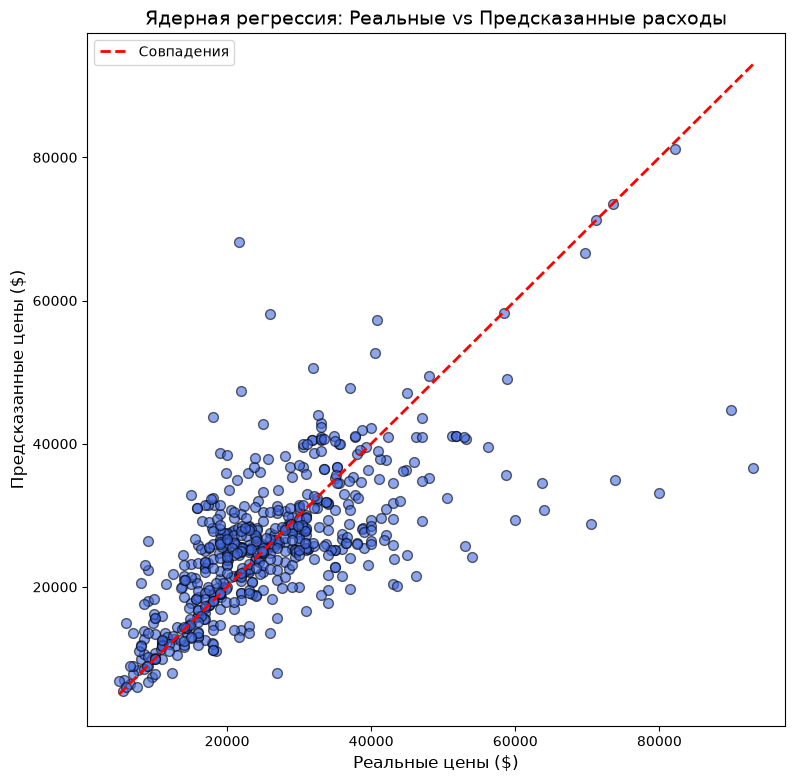

In [7]:
plt.figure(figsize=(9,9))

plt.scatter(y_test, y_pred_nw, alpha=0.6, color="royalblue", edgecolor="k", s=50)

max_val = max(y_test.max(), y_pred_nw.max())
min_val = min(y_test.min(), y_pred_nw.min())

plt.plot(
    [min_val,max_val], [min_val, max_val], "r--", lw=2, label="Совпадения"
)

plt.title("Ядерная регрессия: Реальные vs Предсказанные расходы", fontsize = 14)
plt.xlabel("Реальные цены ($)", fontsize = 12)
plt.ylabel("Предсказанные цены ($)", fontsize = 12)
plt.legend()
plt.show()

## Финальный бизнес-вывод
В результате сравнения двух метрик расстояния модель kNN с Евклидовой метрикой показала лучший результат, в данном датасете Евклидова метрика работает немного эффективнее. Лучший результат показала ядерная регрессия Надарая–Ватсона, получается эта модель точнее двух рассмотренных вариантов kNN. Полученные результаты показывают, что модель способна выявлять зависимость стоимости автомобиля от его характеристик, но точность прогнозирования остаётся ограниченной, так как данные датасета нуждаются в дополнительной обработке, поэтому модель не целесообразно использовать как единственный источник определения цены